In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("AR - performance review - input - Sheet1.csv", header=None)

In [30]:
df

,0,1,2,3,4,5,6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#,CPT Code,Insurance Company,Physician Name,Payment Amount,Balance,Denial Reason
3,1,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
4,2,99214,Aetna,Dr. Johnson,$80.00,$20.00,NaN
5,3,99215,Cigna,Dr. Lee,$0.00,$150.00,45 - Charge exceeds fee schedule
6,4,93000,UnitedHealthcare,Dr. Patel,$50.00,$0.00,NaN
7,5,99212,Blue Cross,Dr. Kim,$0.00,$75.00,96 - Non-covered service
8,6,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
9,7,99214,Aetna,Dr. Johnson,$80.00,$20.00,NaN


In [31]:

df = df.iloc[2:].reset_index(drop=True)
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df.columns = df.columns.str.strip()


In [79]:
df = pd.read_excel("/home/greywind/tensaw/AR - performance review - cleaned.xlsx")

In [65]:
df

,#,CPT Code,Insurance Company,Physician Name,Payment Amount,Balance,Denial Reason
0,1,99213.0,Medicare,Dr. Smith,0.0,100.0,16 - Missing information
1,2,99214.0,Aetna,Dr. Johnson,80.0,20.0,NaN
2,3,99215.0,Cigna,Dr. Lee,0.0,150.0,45 - Charge exceeds fee schedule
3,4,93000.0,UnitedHealthcare,Dr. Patel,50.0,0.0,NaN
4,5,99212.0,Blue Cross,Dr. Kim,0.0,75.0,96 - Non-covered service
5,6,99213.0,Medicare,Dr. Smith,0.0,100.0,16 - Missing information
6,7,99214.0,Aetna,Dr. Johnson,80.0,20.0,NaN
7,8,99215.0,Cigna,Dr. Lee,0.0,150.0,45 - Charge exceeds fee schedule
8,9,93000.0,UnitedHealthcare,Dr. Patel,50.0,0.0,NaN
9,10,99212.0,Blue Cross,Dr. Kim,0.0,75.0,96 - Non-covered service


In [32]:
df

,#,CPT Code,Insurance Company,Physician Name,Payment Amount,Balance,Denial Reason
0,1,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
1,2,99214,Aetna,Dr. Johnson,$80.00,$20.00,NaN
2,3,99215,Cigna,Dr. Lee,$0.00,$150.00,45 - Charge exceeds fee schedule
3,4,93000,UnitedHealthcare,Dr. Patel,$50.00,$0.00,NaN
4,5,99212,Blue Cross,Dr. Kim,$0.00,$75.00,96 - Non-covered service
5,6,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
6,7,99214,Aetna,Dr. Johnson,$80.00,$20.00,NaN
7,8,99215,Cigna,Dr. Lee,$0.00,$150.00,45 - Charge exceeds fee schedule
8,9,93000,UnitedHealthcare,Dr. Patel,$50.00,$0.00,NaN
9,10,99212,Blue Cross,Dr. Kim,$0.00,$75.00,96 - Non-covered service


In [33]:
df = df.dropna(how='any')

In [34]:
df

,#,CPT Code,Insurance Company,Physician Name,Payment Amount,Balance,Denial Reason
0,1,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
2,3,99215,Cigna,Dr. Lee,$0.00,$150.00,45 - Charge exceeds fee schedule
4,5,99212,Blue Cross,Dr. Kim,$0.00,$75.00,96 - Non-covered service
5,6,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
7,8,99215,Cigna,Dr. Lee,$0.00,$150.00,45 - Charge exceeds fee schedule
9,10,99212,Blue Cross,Dr. Kim,$0.00,$75.00,96 - Non-covered service
10,11,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information
12,13,99215,Cigna,Dr. Lee,$0.00,$150.00,45 - Charge exceeds fee schedule
14,15,99212,Blue Cross,Dr. Kim,$0.00,$75.00,96 - Non-covered service
15,16,99213,Medicare,Dr. Smith,$0.00,$100.00,16 - Missing information


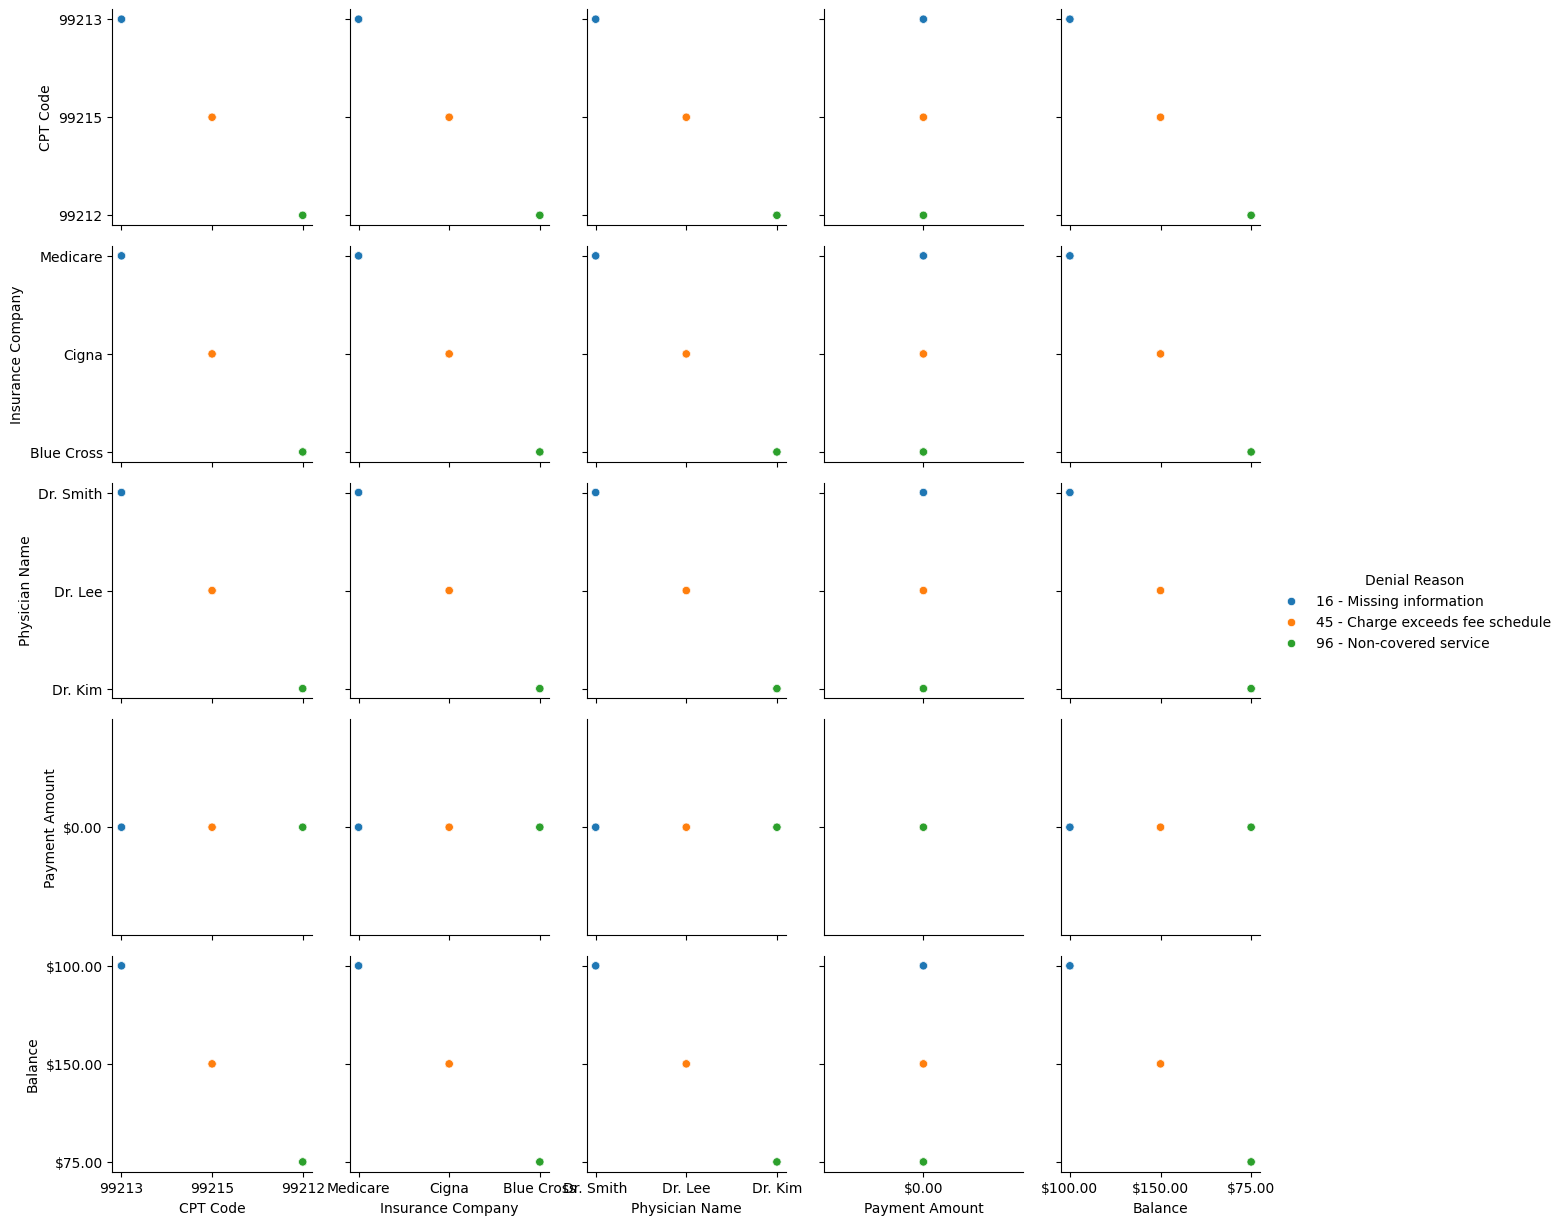

In [35]:
g = sns.PairGrid(
    data=df,
    vars=["CPT Code","Insurance Company","Physician Name","Payment Amount","Balance"],
    hue="Denial Reason",
)
g.map(sns.scatterplot)
g.add_legend()
plt.show()

In [9]:
df = df.drop(columns=["Physician Name","Payment Amount", "Insurance Company", "#"])

In [10]:
df

,CPT Code,Balance,Denial Reason
0,99213,$100.00,16 - Missing information
2,99215,$150.00,45 - Charge exceeds fee schedule
4,99212,$75.00,96 - Non-covered service
5,99213,$100.00,16 - Missing information
7,99215,$150.00,45 - Charge exceeds fee schedule
9,99212,$75.00,96 - Non-covered service
10,99213,$100.00,16 - Missing information
12,99215,$150.00,45 - Charge exceeds fee schedule
14,99212,$75.00,96 - Non-covered service
15,99213,$100.00,16 - Missing information


In [26]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df.loc[:, ["CPT Code","Balance"]] = oe.fit_transform(df[["CPT Code","Balance"]])

In [27]:
df

,CPT Code,Balance,Denial Reason
0,1.0,0.0,16 - Missing information
2,2.0,1.0,45 - Charge exceeds fee schedule
4,0.0,2.0,96 - Non-covered service
5,1.0,0.0,16 - Missing information
7,2.0,1.0,45 - Charge exceeds fee schedule
9,0.0,2.0,96 - Non-covered service
10,1.0,0.0,16 - Missing information
12,2.0,1.0,45 - Charge exceeds fee schedule
14,0.0,2.0,96 - Non-covered service
15,1.0,0.0,16 - Missing information


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = df[["CPT Code","Balance"]]
y = le.fit_transform(df["Denial Reason"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, shuffle=True
)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from sklearn.linear_model import LogisticRegression


clf = LogisticRegression(random_state=0)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


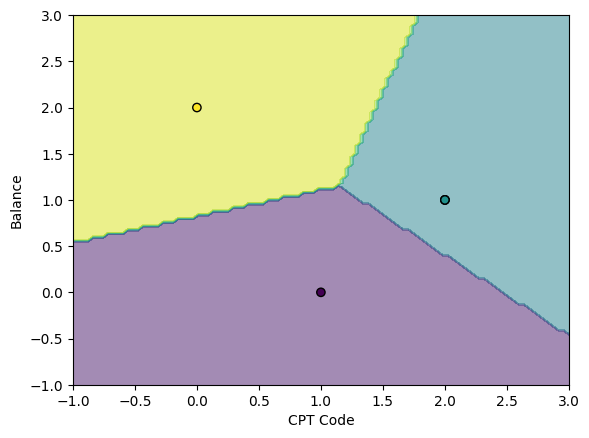

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay


disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(
    X_test["CPT Code"],
    X_test["Balance"],
    c=y_test,
    edgecolor="k",
)
plt.show()

In [23]:
y_test

array([1, 1, 1, 0, 2])

In [24]:
clf.predict(X_test)

array([1, 1, 1, 0, 2])

In [25]:
accuracy = (sum(clf.predict(X_test) == y_test) / len(y_test)) * 100
print(f"Accuracy: {accuracy:.2f} %")

Accuracy: 100.00 %
